<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   id                          30000 non-null  int64
 1   limit_bal                   30000 non-null  int64
 2   sex                         30000 non-null  int64
 3   education                   30000 non-null  int64
 4   marriage                    30000 non-null  int64
 5   age                         30000 non-null  int64
 6   pay_0                       30000 non-null  int64
 7   pay_2                       30000 non-null  int64
 8   pay_3                       30000 non-null  int64
 9   pay_4                       30000 non-null  int64
 10  pay_5                       30000 non-null  int64
 11  pay_6                       30000 non-null  int64
 12  bill_amt1                   30000 non-null  int64
 13  bill_amt2                   30000 non-null  int64
 14  bill_amt3        

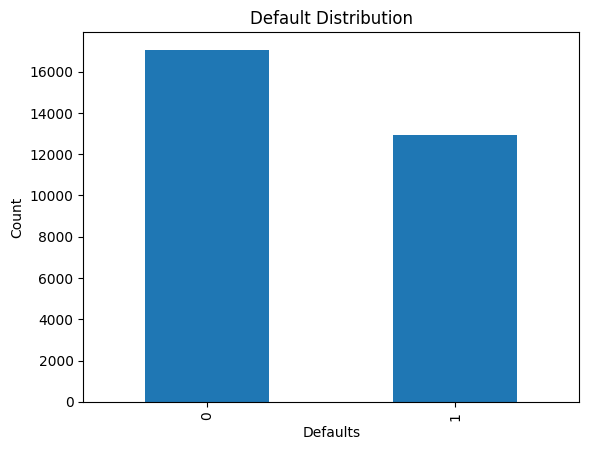

Imbalance Ratio: 1.32:1
Done
logistic_regression
ROC AUC: 0.8974453744553751
Average Precision: 0.8772038606948904

random_forest
ROC AUC: 0.8683394180937574
Average Precision: 0.8449912899424268

Best model: logistic_regression
[[2691  720]
 [ 619 1970]]
              precision    recall  f1-score   support

           0       0.81      0.79      0.80      3411
           1       0.73      0.76      0.75      2589

    accuracy                           0.78      6000
   macro avg       0.77      0.77      0.77      6000
weighted avg       0.78      0.78      0.78      6000

All done


In [20]:
%run Uploading_Model_Artifacts.ipynb

| Probability of Default (PD) | Risk Band | Interpretation | Decision             |
| --------------------------- | --------- | -------------- | -------------------- |
| 0.00 – 0.05                 | A         | Very Low Risk  | Approve              |
| 0.05 – 0.10                 | B         | Low Risk       | Approve              |
| 0.10 – 0.20                 | C         | Medium Risk    | Manual Review        |
| 0.20 – 0.35                 | D         | High Risk      | Conditional Approval |
| > 0.35                      | E         | Very High Risk | Decline              |


In [21]:
import boto3
import json

s3 = boto3.client("s3")

obj = s3.get_object(
    Bucket="newmlopsbucket",
    Key="models/champion/feature_schema.json"
)

schema = json.loads(obj["Body"].read())

print(schema)

{'numeric_features': ['limit_bal', 'age', 'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'bill_amt1', 'bill_amt2', 'bill_amt3', 'bill_amt4', 'bill_amt5', 'bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6'], 'categorical_features': [], 'target': 'default_payment_next_month', 'best_model': 'logistic_regression'}


In [22]:
import pandas as pd

data = [
    {
        "id": 1,
        "limit_bal": 20000,
        "sex": 2,
        "education": 2,
        "marriage": 1,
        "age": 24,
        "pay_0": 2,
        "pay_2": 2,
        "pay_3": -1,
        "pay_4": -1,
        "pay_5": -2,
        "pay_6": -2,
        "bill_amt1": 3913,
        "bill_amt2": 3102,
        "bill_amt3": 689,
        "bill_amt4": 0,
        "bill_amt5": 0,
        "bill_amt6": 0,
        "pay_amt1": 0,
        "pay_amt2": 689,
        "pay_amt3": 0,
        "pay_amt4": 0,
        "pay_amt5": 0,
        "pay_amt6": 0
    },
    {
        "id": 2,
        "limit_bal": 120000,
        "sex": 2,
        "education": 2,
        "marriage": 2,
        "age": 26,
        "pay_0": -1,
        "pay_2": 2,
        "pay_3": 0,
        "pay_4": 0,
        "pay_5": 0,
        "pay_6": 2,
        "bill_amt1": 2682,
        "bill_amt2": 1725,
        "bill_amt3": 2682,
        "bill_amt4": 3272,
        "bill_amt5": 3455,
        "bill_amt6": 3261,
        "pay_amt1": 0,
        "pay_amt2": 1000,
        "pay_amt3": 1000,
        "pay_amt4": 1000,
        "pay_amt5": 0,
        "pay_amt6": 2000
    },
    {
        "id": 3,
        "limit_bal": 90000,
        "sex": 1,
        "education": 1,
        "marriage": 2,
        "age": 39,
        "pay_0": 0,
        "pay_2": 0,
        "pay_3": 0,
        "pay_4": 0,
        "pay_5": 0,
        "pay_6": 0,
        "bill_amt1": 50000,
        "bill_amt2": 49000,
        "bill_amt3": 48000,
        "bill_amt4": 47000,
        "bill_amt5": 46000,
        "bill_amt6": 45000,
        "pay_amt1": 2000,
        "pay_amt2": 2000,
        "pay_amt3": 2000,
        "pay_amt4": 2000,
        "pay_amt5": 2000,
        "pay_amt6": 2000
    },
   { 
      "id": 1001,
      "limit_bal": 200000,
      "sex": 2,
      "education": 1,
      "marriage": 2,
      "age": 35,
      "pay_0": 0,
      "pay_2": 0,
      "pay_3": 0,
      "pay_4": 0,
      "pay_5": 0,
      "pay_6": 0,
      "bill_amt1": 15000,
      "bill_amt2": 14000,
      "bill_amt3": 13000,
      "bill_amt4": 12000,
      "bill_amt5": 11000,
      "bill_amt6": 10000,
      "pay_amt1": 15000,
      "pay_amt2": 14000,
      "pay_amt3": 13000,
      "pay_amt4": 12000,
      "pay_amt5": 11000,
      "pay_amt6": 10000
    }
]

df = pd.DataFrame(data)

# Save locally
file_name = "new_applications.csv"
df.to_csv(file_name, index=False)

print("CSV created successfully!")
print(df.head())

CSV created successfully!
     id  limit_bal  sex  education  marriage  age  pay_0  pay_2  pay_3  pay_4  \
0     1      20000    2          2         1   24      2      2     -1     -1   
1     2     120000    2          2         2   26     -1      2      0      0   
2     3      90000    1          1         2   39      0      0      0      0   
3  1001     200000    2          1         2   35      0      0      0      0   

   ...  bill_amt3  bill_amt4  bill_amt5  bill_amt6  pay_amt1  pay_amt2  \
0  ...        689          0          0          0         0       689   
1  ...       2682       3272       3455       3261         0      1000   
2  ...      48000      47000      46000      45000      2000      2000   
3  ...      13000      12000      11000      10000     15000     14000   

   pay_amt3  pay_amt4  pay_amt5  pay_amt6  
0         0         0         0         0  
1      1000      1000         0      2000  
2      2000      2000      2000      2000  
3     13000     12000

In [23]:
import boto3

s3 = boto3.client("s3")

BUCKET = "newmlopsbucket"

s3.upload_file(
    Filename="new_applications.csv",
    Bucket=BUCKET,
    Key="scoring/input/new_applications.csv"
)

print("Upload successful to S3!")

Upload successful to S3!


In [24]:
response = s3.list_objects_v2(
    Bucket=BUCKET,
    Prefix="scoring/input/"
)

for obj in response.get("Contents", []):
    print(obj["Key"])

scoring/input/
scoring/input/new_applications.csv


In [25]:
# =====================================================
# Imports
# =====================================================

import boto3
import pandas as pd
import joblib

# =====================================================
# S3 Configuration
# =====================================================

BUCKET = "newmlopsbucket"

s3 = boto3.client("s3")

# =====================================================
# Download Champion Model
# =====================================================

s3.download_file(
    BUCKET,
    "models/champion/credit_risk_model.joblib",
    "credit_risk_model.joblib"
)

print("Model downloaded successfully.")

# =====================================================
# Load Model
# =====================================================

model = joblib.load("credit_risk_model.joblib")

print("Model loaded successfully.")

# =====================================================
# Load New Applications
# =====================================================

obj = s3.get_object(
    Bucket=BUCKET,
    Key="scoring/input/new_applications.csv"
)

new_apps = pd.read_csv(obj["Body"])

print(f"{len(new_apps)} applications loaded.")

# =====================================================
# Preserve IDs
# =====================================================

id_columns = []

for col in ["customer_id", "loan_id"]:
    if col in new_apps.columns:
        id_columns.append(col)

if id_columns:
    ids = new_apps[id_columns].copy()
else:
    ids = pd.DataFrame(index=new_apps.index)

# =====================================================
# Prepare Features
# =====================================================

X_new = new_apps.drop(
    columns=id_columns,
    errors="ignore"
)

# =====================================================
# Generate Predictions
# =====================================================

default_probability = model.predict_proba(X_new)[:, 1]

# =====================================================
# Create Output DataFrame
# =====================================================

scored = ids.copy()

scored["probability_of_default"] = default_probability

# =====================================================
# Risk Band Logic
# =====================================================

def risk_band(probability):

    if probability < 0.05:
        return "A"

    elif probability < 0.10:
        return "B"

    elif probability < 0.20:
        return "C"

    elif probability < 0.35:
        return "D"

    else:
        return "E"

scored["risk_band"] = scored[
    "probability_of_default"
].apply(risk_band)

# =====================================================
# Recommendation Logic
# =====================================================

def recommendation(band):

    if band in ["A", "B"]:
        return "Approve"

    elif band == "C":
        return "Manual Review"

    elif band == "D":
        return "Approve With Conditions"

    else:
        return "Decline"

scored["recommendation"] = scored[
    "risk_band"
].apply(recommendation)

# =====================================================
# Preview Results
# =====================================================

display(scored.head())

# =====================================================
# Save Locally
# =====================================================

output_file = "scored_applications.csv"

scored.to_csv(
    output_file,
    index=False
)

print("Scored file saved locally.")

# =====================================================
# Upload Results to S3
# =====================================================

s3.upload_file(
    output_file,
    BUCKET,
    "scoring/output/scored_applications.csv"
)

print("Scored file uploaded to S3.")

# =====================================================
# Summary
# =====================================================

print(f"Applications scored: {len(scored)}")

print(
    scored["risk_band"]
    .value_counts()
    .sort_index()
)

Model downloaded successfully.
Model loaded successfully.
4 applications loaded.


,probability_of_default,risk_band,recommendation
0,0.678140,E,Decline
1,0.373453,E,Decline
2,0.515081,E,Decline
3,0.077772,B,Approve


Scored file saved locally.
Scored file uploaded to S3.
Applications scored: 4
risk_band
B    1
E    3
Name: count, dtype: int64


**Model is trained using a Random Forest classifier
Features are derived from historical credit card repayment behavior
Output is a probability score, not a binary decision
Final decision is controlled by policy thresholds (not the model itself**